## Imports

In [1]:
from pathlib import Path
import subprocess
import sys
from itertools import product
from dataclasses import fields, asdict, is_dataclass
import json
import time
import traceback
import pandas as pd

from instance_reader import read_instance
from initial_solution import greedy_initial_solution


from alns import (
    SAParams, PenaltyParams, ALNSParams, run_alns,
    RandomRemoval, WorstDensityRemoval, SkillScarcityRemoval,
    RelatedRemoval, WorstDetourRemoval, WorstDetourRemovalV2,
    ShawRelatedRemoval, RouteRemoval, TimeWindowSegmentRemoval,
    GreedyBestInsertionRepair, Regret2InsertionRepair,
    SequentialCheapestInsertionRepair, NoisyGreedyInsertionRepair,
    ScarceSkillFirstRepair,
    # neue Operatoren (Kovacs et al. 2012, Hammami et al. 2020)
    SequenceRemoval, ClusterRemoval, LargestSavingRemoval, TemporalShawRemoval,
    RegretKInsertionRepair, LastRemovedFirstInsertedRepair,
    RandomPositionInsertionRepair,
    HistoryBasedRemoval, ShawInsertionRepair,
)

## Playground

In [2]:
instance_path = Path("dataset/skillvrp_n400_v10_s8_k2.0_10.txt")
checker_path = Path("checker.py")

solution_dir = Path("solutions")
solution_dir.mkdir(parents=True, exist_ok=True)

solution_path = solution_dir / "solution.txt"

In [3]:
inst = read_instance(str(instance_path))

In [4]:
start_solution = greedy_initial_solution(
    inst,
    strategy="multi_start",
    verbose=True,
)

print("Initial objective:", start_solution.objective)

Greedy strategy: hybrid
  Objective: 9750
  Served customers: 128/400
Greedy strategy: profit
  Objective: 10426
  Served customers: 122/400
Greedy strategy: density
  Objective: 10255
  Served customers: 130/400
Greedy strategy: fewest_vehicles
  Objective: 10035
  Served customers: 122/400

Selected greedy strategy: profit
Best objective: 10426
Served customers: 122/400
Initial objective: 10426


In [5]:
sa = SAParams(
    initial_temperature=100.0,
    min_temperature=0.001,
    cooling_rate=0.9995,
    reheat_factor=0.75,
)

penalties = PenaltyParams(
    time_window_penalty=20.0,
    shift_penalty=20.0,
    skill_penalty=10000.0,
)

params = ALNSParams(
    random_seed=1,
    segment_length=100,
    no_accept_limit=500,
    reaction_factor=0.20,
    min_operator_weight=0.05,
    score_global_best=25.0,
    score_better_current=10.0,
    score_accepted=3.0,
    score_rejected=0.0,
    time_cost_alpha=0.5,
    time_scale_seconds=0.01,
    verbose=True,
    polish_interval_seconds=0.0,   # >0 aktiviert den v2 Or-opt-Polish auf neuen Best-Lösungen
)


destroy_operators = [
    RandomRemoval(
        fraction=0.15,
        min_remove=1,
        max_remove=50,
        initial_weight=1.0,
    ),
    WorstDensityRemoval(
        fraction=0.15,
        min_remove=1,
        max_remove=50,
        noise=0.05,
        initial_weight=1.0,
    ),
    SkillScarcityRemoval(
        fraction=0.15,
        min_remove=1,
        max_remove=50,
        noise=0.05,
        initial_weight=1.0,
    ),
    # --- aus alns(1), vorher nicht in der Liste ---
    RelatedRemoval(
        fraction=0.20,
        min_remove=1,
        max_remove=50,
        bias=4.0,
        initial_weight=1.0,
    ),
    WorstDetourRemoval(
        fraction=0.15,
        min_remove=1,
        max_remove=50,
        bias=4.0,
        initial_weight=1.0,
    ),
    # --- neu gemergt aus alns.py ---
    WorstDetourRemovalV2(
        fraction=0.15,
        min_remove=1,
        max_remove=50,
        noise=0.05,
        selection_bias=3.0,
        initial_weight=1.0,
    ),
    ShawRelatedRemoval(
        fraction=0.20,
        min_remove=1,
        max_remove=50,
        p_determinism=4.0,
        w_distance=0.5,
        w_time=0.25,
        w_skill=0.25,
        initial_weight=1.0,
    ),
    RouteRemoval(
        max_routes=2,
        selection_bias=3.0,
        initial_weight=1.0,
    ),
    TimeWindowSegmentRemoval(
        window_fraction=0.15,
        max_remove=50,
        initial_weight=1.0,
    ),
]

repair_operators = [
    GreedyBestInsertionRepair(
        extra_unserved_limit=100,
        max_insertions=None,
        min_delta_score=0.0,
        initial_weight=1.0,
    ),
    Regret2InsertionRepair(
        extra_unserved_limit=100,
        max_insertions=None,
        min_delta_score=0.0,
        initial_weight=1.0,
    ),
    # --- aus alns(1), vorher nicht in der Liste ---
    SequentialCheapestInsertionRepair(
        extra_unserved_limit=100,
        order="profit",
        initial_weight=1.0,
        noise_amp=0.0,
    ),
    # --- neu gemergt aus alns.py ---
    NoisyGreedyInsertionRepair(
        extra_unserved_limit=100,
        max_insertions=None,
        min_delta_score=0.0,
        noise=0.15,
        initial_weight=1.0,
    ),
    ScarceSkillFirstRepair(
        extra_unserved_limit=100,
        min_delta_score=0.0,
        initial_weight=1.0,
    ),
]

In [ ]:
result = run_alns(
    runtime=30.0,
    inst=inst,
    start_solution=start_solution,
    sa=sa,
    params=params,
    penalties=penalties,
    destroy_operators=destroy_operators,
    repair_operators=repair_operators,
)

print()
print("ALNS finished")
print("Best objective:", result.best_evaluation.profit)
print("Best penalty:", result.best_evaluation.penalty)
print("Best feasible:", result.best_evaluation.feasible)
print("Iterations:", result.iterations)
print("Restarts:", result.restarts)

iter=    100 | best=   12067 | current_score=  12064.00 | current_feasible=True | T= 67.3636
iter=    200 | best=   12311 | current_score=  12161.00 | current_feasible=True | T= 46.6295
iter=    300 | best=   12498 | current_score=  12460.00 | current_feasible=True | T= 34.0067
iter=    400 | best=   12498 | current_score=  12481.00 | current_feasible=True | T= 23.9767
iter=    500 | best=   12654 | current_score=  12654.00 | current_feasible=True | T= 16.5407
iter=    600 | best=   12654 | current_score=  12640.00 | current_feasible=True | T= 11.6948
iter=    700 | best=   12690 | current_score=  12690.00 | current_feasible=True | T=  7.9270
iter=    800 | best=   12690 | current_score=  12681.00 | current_feasible=True | T=  5.4447
iter=    900 | best=   12690 | current_score=  12681.00 | current_feasible=True | T=  3.8540
iter=   1000 | best=   12690 | current_score=  12681.00 | current_feasible=True | T=  2.6604
iter=   1100 | best=   12690 | current_score=  12681.00 | current_feas

### Checker writing

In [7]:
result.best_solution.write_for_checker(str(solution_path))

In [8]:
checker_result = subprocess.run(
    [
        sys.executable,
        str(checker_path),
        str(instance_path),
        str(solution_path),
    ],
    capture_output=True,
    text=True,
)

print()
print("Checker stdout:")
print(checker_result.stdout)

if checker_result.stderr:
    print("Checker stderr:")
    print(checker_result.stderr)

print("Checker return code:", checker_result.returncode)


Checker stdout:
OK: feasible, profit = 12832, visited 161/400 customers

Checker return code: 0


## Grid search:

In [3]:
# --- Gemeinsame Operator-Factory fuer Grid Search UND Benchmark -----------
# Operatoren sind zustandsbehaftet (weight, total_uses, segment_*): jeder
# run_alns-Aufruf braucht ein frisches, unabhaengiges Set.
# Ohne setup-Dict gelten die Defaults der besten bekannten Benchmark-Config
# (fraction-Bereiche, extra_unserved_limit=40, max_remove-Kappung bei 100);
# die Grid Search uebergibt ihr setup aus make_setup_grid().

def make_operators(inst, setup: dict | None = None):
    n = inst.num_customers

    # Bruchteil der Instanzgroesse, absolut bei 100 gekappt: ohne Kappung
    # werden die Repairs auf grossen Instanzen so teuer, dass die
    # Iterationszahl einbricht (n=1000 waeren 250+ entfernte Kunden/Iteration).
    ratio = setup["max_remove_ratio"] if setup else 0.25
    max_remove = max(5, min(100, int(round(n * ratio))))

    bf = setup["base_fraction"] if setup else (0.05, 0.15)       # Basis-Destroy
    rf = setup["related_fraction"] if setup else (0.05, 0.20)    # Related/Shaw
    eul = setup["extra_unserved_limit"] if setup else 40         # Repair-Kandidatenpool
    mds = setup.get("min_delta_score", 0.0) if setup else 0.0

    # Time-based removal = Shaw nur mit Zeitterm (Demir et al. 2012).
    # Eigener Name, sonst vermischen Tracking und Summaries die beiden
    # ShawRelatedRemoval-Instanzen.
    time_based = ShawRelatedRemoval(
        fraction=rf, min_remove=1, max_remove=max_remove,
        p_determinism=4.0, w_distance=0.0, w_time=1.0, w_skill=0.0,
        initial_weight=1.0, neighbor_limit=100,
    )
    time_based.name = "time_based_removal"

    destroy_operators = [

        # --- Basis-Operatoren ---
        RandomRemoval(
            fraction=bf, min_remove=1, max_remove=max_remove,
            initial_weight=1.0,
        ),
        WorstDensityRemoval(
            fraction=bf, min_remove=1, max_remove=max_remove,
            noise=0.05, initial_weight=1.0,
        ),
        SkillScarcityRemoval(
            fraction=bf, min_remove=1, max_remove=max_remove,
            noise=0.05, initial_weight=1.0,
        ),
        RelatedRemoval(
            fraction=rf, min_remove=1, max_remove=max_remove,
            bias=4.0, initial_weight=1.0,
        ),

        # --- Detour-basiert ---
        WorstDetourRemoval(
            fraction=bf, min_remove=1, max_remove=max_remove,
            bias=4.0, initial_weight=1.0,
        ),
        WorstDetourRemovalV2(
            fraction=bf, min_remove=1, max_remove=max_remove,
            noise=0.05, selection_bias=3.0, initial_weight=1.0,
        ),

        # --- Shaw / verwandte Cluster ---
        ShawRelatedRemoval(
            fraction=rf, min_remove=1, max_remove=max_remove,
            p_determinism=4.0, w_distance=0.5, w_time=0.25, w_skill=0.25,
            initial_weight=1.0,
        ),
        time_based,

        # --- Routen- / Fenster-basiert ---
        RouteRemoval(
            max_routes=2, selection_bias=3.0, initial_weight=1.0,
        ),
        TimeWindowSegmentRemoval(
            window_fraction=0.15, max_remove=max_remove, initial_weight=1.0,
        ),

        # --- Literatur-basierte Erweiterungen ---
        SequenceRemoval(
            fraction=bf, min_remove=1, max_remove=max_remove, initial_weight=1.0,
        ),
        ClusterRemoval(
            fraction=bf, min_remove=1, max_remove=max_remove, initial_weight=1.0,
        ),
        LargestSavingRemoval(
            fraction=bf, min_remove=1, max_remove=max_remove,
            selection_bias=3.0, initial_weight=1.0,
        ),
        TemporalShawRemoval(
            fraction=rf, min_remove=1, max_remove=max_remove,
            p_determinism=4.0, w_distance=0.5, w_time=0.25, w_skill=0.25,
            initial_weight=1.0,
        ),
        HistoryBasedRemoval(
            fraction=bf, min_remove=1, max_remove=max_remove,
            selection_bias=3.0, initial_weight=1.0,
        ),
    ]

    repair_operators = [
        GreedyBestInsertionRepair(
            extra_unserved_limit=eul, max_insertions=None,
            min_delta_score=mds, initial_weight=1.0,
        ),
        Regret2InsertionRepair(
            extra_unserved_limit=eul, max_insertions=None,
            min_delta_score=mds, initial_weight=1.0,
        ),
        SequentialCheapestInsertionRepair(
            extra_unserved_limit=eul, order="profit",
            initial_weight=1.0,
        ),
        NoisyGreedyInsertionRepair(
            extra_unserved_limit=eul, max_insertions=None,
            min_delta_score=mds, noise=0.15, initial_weight=1.0,
        ),
        ScarceSkillFirstRepair(
            extra_unserved_limit=eul,
            min_delta_score=mds, initial_weight=1.0,
        ),
        LastRemovedFirstInsertedRepair(
            extra_unserved_limit=eul,
            min_delta_score=mds, initial_weight=1.0,
        ),
        RegretKInsertionRepair(
            extra_unserved_limit=eul, max_insertions=None,
            min_delta_score=mds, k=3, initial_weight=1.0,
        ),
        RandomPositionInsertionRepair(
            extra_unserved_limit=eul, initial_weight=1.0,
        ),
        ShawInsertionRepair(
            extra_unserved_limit=eul, min_delta_score=mds,
            p_determinism=4.0, w_distance=0.5, w_time=0.25, w_skill=0.25,
            initial_weight=1.0,
        ),
    ]

    return destroy_operators, repair_operators

In [3]:

DATASET_DIR = Path("dataset")
OUT_DIR = Path("gridsearch_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

INSTANCE_NAMES = [
    "skillvrp_n100_v2_s5_k1.0_3.txt",
    "skillvrp_n450_v11_s3_k0.0_11.txt",
    "skillvrp_n1000_v25_s8_k2.0_20.txt",
]

RUNTIME_PER_RUN = 30.0   # = finales Evaluations-Budget: tunen und messen im selben Regime
TOP_K = 3

# Gleiche Seeds fuer ALLE Setups (common random numbers): Setup-Vergleiche
# messen dann Parameter-Effekte, nicht Zufallsstreuung. Gemittelt wird ueber
# Instanzen x Seeds.
SEEDS = [1, 2]

OPTIMISM_MARGIN = 0.02


TEMP_FACTORS = [0.8, 1.5]

# Fractions als (lo, hi)-Bereiche: number_to_remove sampelt pro Aufruf, d.h.
# kleine Polier-Schritte und grosse Restrukturierungen gemischt.
# max_remove_ratio ist bewusst KEIN Grid-Parameter mehr: in den alten
# Profilen lag die Kappung immer ueber der groessten Fraction und war damit
# wirkungslos; jetzt ist sie konstant 0.25 (absolut bei 100 gekappt, siehe
# make_operators).
DESTROY_PROFILES = [
    {   # konservativ: kleine Schnitte, viel Feinschliff
        "name": "small",
        "base_fraction": (0.03, 0.10),
        "related_fraction": (0.05, 0.15),
        "no_accept_limit": 700,
    },
    {   # = aktuelle Benchmark-Defaults (Referenzpunkt)
        "name": "medium",
        "base_fraction": (0.05, 0.15),
        "related_fraction": (0.05, 0.20),
        "no_accept_limit": 500,
    },
    {   # aggressiv: grosse Restrukturierungen
        "name": "large",
        "base_fraction": (0.10, 0.22),
        "related_fraction": (0.10, 0.28),
        "no_accept_limit": 350,
    },
]

EXTRA_UNSERVED_LIMITS = [25, 40, 60]   # klammert den bekannten Gewinner 40 ein

# Penalty fixiert auf "medium": Penalties wirken nur auf infeasible
# Zwischenloesungen und waren in allen bisherigen Laeufen die am wenigsten
# informative Achse -- das Budget steckt jetzt in extra-Levels und Seeds.
PENALTY_LEVELS = [
    {
        "name": "medium",
        "time_window_penalty": 20.0,
        "shift_penalty": 20.0,
        "skill_penalty": 10000.0,
    },
]


def dataclass_kwargs(cls, kwargs: dict) -> dict:

    allowed = {f.name for f in fields(cls)}
    return {k: v for k, v in kwargs.items() if k in allowed}


def make_setup_grid() -> list[dict]:
    setups = []

    setup_id = 0
    for temp_factor, destroy_profile, extra_limit, penalty_level in product(
        TEMP_FACTORS,
        DESTROY_PROFILES,
        EXTRA_UNSERVED_LIMITS,
        PENALTY_LEVELS,
    ):
        setup_id += 1

        setup = {
            "setup_id": setup_id,

            "temp_factor": temp_factor,

            "destroy_profile": destroy_profile["name"],
            "base_fraction": destroy_profile["base_fraction"],
            "related_fraction": destroy_profile["related_fraction"],
            "max_remove_ratio": 0.25,
            "no_accept_limit": destroy_profile["no_accept_limit"],

            "extra_unserved_limit": extra_limit,

            "penalty_profile": penalty_level["name"],
            "time_window_penalty": penalty_level["time_window_penalty"],
            "shift_penalty": penalty_level["shift_penalty"],
            "skill_penalty": penalty_level["skill_penalty"],

            "segment_length": 100,
            "reaction_factor": 0.20,
            "min_operator_weight": 0.05,
            "time_cost_alpha": 0.5,
            "time_scale_seconds": 0.01,
            "polish_interval_seconds": 0.0,

            "score_global_best": 25.0,
            "score_better_current": 10.0,
            "score_accepted": 3.0,
            "score_rejected": 0.0,

            "min_delta_score": 0.0,
        }

        setups.append(setup)

    return setups


def make_params_for_setup(
    setup: dict,
    seed: int,
    segment_length: int | None = None,
) -> ALNSParams:
    kwargs = {
        "random_seed": seed,
        "segment_length": (
            segment_length if segment_length is not None
            else setup["segment_length"]
        ),
        "no_accept_limit": setup["no_accept_limit"],

        "reaction_factor": setup["reaction_factor"],
        "min_operator_weight": setup["min_operator_weight"],

        "score_global_best": setup["score_global_best"],
        "score_better_current": setup["score_better_current"],
        "score_accepted": setup["score_accepted"],
        "score_rejected": setup["score_rejected"],

        "time_cost_alpha": setup["time_cost_alpha"],
        "time_scale_seconds": setup["time_scale_seconds"],

        "verbose": False,


        "polish_interval_seconds": setup["polish_interval_seconds"],
    }

    return ALNSParams(**dataclass_kwargs(ALNSParams, kwargs))


def make_sa_for_setup(setup: dict, inst, start_solution) -> SAParams:
    served = inst.num_customers - len(start_solution.unserved)
    avg_profit = start_solution.objective / max(1, served)

    initial_temperature = max(10.0, setup["temp_factor"] * avg_profit)

    return SAParams(
        initial_temperature=initial_temperature,
        min_temperature=0.001,
        cooling_rate=0.9995,
        reheat_factor=0.75,
    )


def make_penalties_for_setup(setup: dict) -> PenaltyParams:
    return PenaltyParams(
        time_window_penalty=setup["time_window_penalty"],
        shift_penalty=setup["shift_penalty"],
        skill_penalty=setup["skill_penalty"],
    )


def update_top3(top3: list[dict], summary: dict) -> list[dict]:
    top3.append(summary)
    top3.sort(key=lambda row: row["avg_improvement"], reverse=True)
    return top3[:TOP_K]


def worst_top3_score(top3: list[dict]) -> float | None:
    if len(top3) < TOP_K:
        return None
    return top3[-1]["avg_improvement"]



instance_data = []

for name in INSTANCE_NAMES:
    path = DATASET_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Instanz nicht gefunden: {path}")

    print(f"Lese Instanz und baue Startlösung: {name}")
    inst = read_instance(str(path))

    t0 = time.perf_counter()
    start_solution = greedy_initial_solution(
        inst,
        strategy="multi_start",
        verbose=False,
    )
    start_time = time.perf_counter() - t0

    instance_data.append(
        {
            "name": name,
            "path": path,
            "inst": inst,
            "start_solution": start_solution,
            "start_profit": start_solution.objective,
            "start_time": start_time,
        }
    )

    print(
        f"  start objective={start_solution.objective}, "
        f"start_time={start_time:.2f}s"
    )



setups = make_setup_grid()

all_rows = []
setup_summaries = []
top3 = []


# Eine Run-Einheit = (Instanz, Seed); Racing-Bound und Mittelung laufen
# ueber alle Einheiten.
run_units = [(item, seed) for item in instance_data for seed in SEEDS]

best_seen_improvement_by_unit = {
    (item["name"], seed): 0.0
    for item, seed in run_units
}

grid_start = time.perf_counter()

for setup_idx, setup in enumerate(setups, start=1):
    print()
    print("=" * 90)
    print(
        f"Setup {setup_idx}/{len(setups)} | "
        f"id={setup['setup_id']} | "
        f"T={setup['temp_factor']} | "
        f"destroy={setup['destroy_profile']} | "
        f"extra={setup['extra_unserved_limit']} | "
        f"penalty={setup['penalty_profile']}"
    )

    setup_rows = []
    stopped_early = False
    failed = False

    for item, seed in run_units:
        inst_name = item["name"]
        inst = item["inst"]
        start_solution = item["start_solution"]
        start_profit = item["start_profit"]

        sa = make_sa_for_setup(setup, inst, start_solution)
        penalties = make_penalties_for_setup(setup)
        params = make_params_for_setup(
            setup,
            seed=seed,
            # Wie im Benchmark: kuerzere Segmente auf grossen Instanzen,
            # sonst kommen die adaptiven Gewichte dort nie zum Zug.
            segment_length=50 if inst.num_customers >= 500 else 100,
        )
        destroy_ops, repair_ops = make_operators(inst, setup)

        print(f"  Run {inst_name} (seed={seed}) ...", end=" ")

        t0 = time.perf_counter()

        try:
            result = run_alns(
                runtime=RUNTIME_PER_RUN,
                inst=inst,
                start_solution=start_solution,
                sa=sa,
                params=params,
                penalties=penalties,
                destroy_operators=destroy_ops,
                repair_operators=repair_ops,
            )

            elapsed = time.perf_counter() - t0

            best_profit = result.best_evaluation.profit
            feasible = result.best_evaluation.feasible

            if feasible:
                improvement = (
                    (best_profit - start_profit) / max(1, start_profit)
                )
            else:
                # In der Regel sollte das nicht passieren, weil die Startlösung feasible ist.
                # Falls doch, wird das Setup hart bestraft.
                improvement = -1.0

            best_seen_improvement_by_unit[(inst_name, seed)] = max(
                best_seen_improvement_by_unit[(inst_name, seed)],
                improvement,
            )

            row = {
                **setup,
                "instance": inst_name,
                "n_customers": inst.num_customers,
                "seed": seed,
                "runtime_limit": RUNTIME_PER_RUN,
                "elapsed": elapsed,

                "start_profit": start_profit,
                "best_profit": best_profit,
                "improvement": improvement,
                "improvement_pct": 100.0 * improvement,

                "feasible": feasible,
                "penalty": result.best_evaluation.penalty,
                "score": result.best_evaluation.score,
                "iterations": result.iterations,
                "restarts": result.restarts,

                "destroy_summary": result.destroy_summary,
                "repair_summary": result.repair_summary,
                "error": "",
            }

            print(
                f"{start_profit} -> {best_profit} "
                f"({100.0 * improvement:+.2f}%, "
                f"{result.iterations} it, {result.restarts} rs)"
            )

        except Exception as exc:
            elapsed = time.perf_counter() - t0
            failed = True

            row = {
                **setup,
                "instance": inst_name,
                "n_customers": inst.num_customers,
                "seed": seed,
                "runtime_limit": RUNTIME_PER_RUN,
                "elapsed": elapsed,

                "start_profit": start_profit,
                "best_profit": 0,
                "improvement": -1.0,
                "improvement_pct": -100.0,

                "feasible": False,
                "penalty": None,
                "score": None,
                "iterations": 0,
                "restarts": 0,

                "destroy_summary": [],
                "repair_summary": [],
                "error": repr(exc),
            }

            print("FAILED")
            print(traceback.format_exc())

        setup_rows.append(row)
        all_rows.append(row)

        # Zwischenergebnisse direkt sichern, falls der Notebook-Kernel stoppt.
        pd.DataFrame(all_rows).drop(
            columns=["destroy_summary", "repair_summary"],
            errors="ignore",
        ).to_csv(OUT_DIR / "gridsearch_all_runs.csv", index=False)

        if failed:
            stopped_early = True
            break

        cutoff = worst_top3_score(top3)

        if cutoff is not None and len(setup_rows) < len(run_units):
            done_units = {(r["instance"], r["seed"]) for r in setup_rows}
            remaining_units = [
                (unit_item["name"], unit_seed)
                for unit_item, unit_seed in run_units
                if (unit_item["name"], unit_seed) not in done_units
            ]

            partial_sum = sum(r["improvement"] for r in setup_rows)

            optimistic_remaining = 0.0
            for unit in remaining_units:
                optimistic_remaining += (
                    best_seen_improvement_by_unit[unit]
                    + OPTIMISM_MARGIN
                )

            optimistic_avg = (
                partial_sum + optimistic_remaining
            ) / len(run_units)

            if optimistic_avg < cutoff:
                stopped_early = True
                print(
                    f"  Early stop: optimistic_avg={100.0 * optimistic_avg:.2f}% "
                    f"< current_top3_cutoff={100.0 * cutoff:.2f}%"
                )
                break

    completed = (
        not stopped_early
        and not failed
        and len(setup_rows) == len(run_units)
    )

    if completed:
        avg_improvement = sum(r["improvement"] for r in setup_rows) / len(setup_rows)
        avg_profit = sum(r["best_profit"] for r in setup_rows) / len(setup_rows)
        all_feasible = all(r["feasible"] for r in setup_rows)

        summary = {
            **setup,
            "avg_improvement": avg_improvement,
            "avg_improvement_pct": 100.0 * avg_improvement,
            "avg_best_profit": avg_profit,
            "all_feasible": all_feasible,
            "completed_instances": len(setup_rows),
            "total_elapsed": sum(r["elapsed"] for r in setup_rows),
            "per_instance": [
                {
                    "instance": r["instance"],
                    "seed": r["seed"],
                    "start_profit": r["start_profit"],
                    "best_profit": r["best_profit"],
                    "improvement_pct": r["improvement_pct"],
                    "iterations": r["iterations"],
                    "restarts": r["restarts"],
                    "feasible": r["feasible"],
                }
                for r in setup_rows
            ],
        }

        setup_summaries.append(summary)
        top3 = update_top3(top3, summary)

        print(
            f"  Completed setup avg improvement: "
            f"{100.0 * avg_improvement:+.2f}%"
        )
    else:
        print("  Setup nicht vollständig bewertet.")

    # Top3 nach jedem Setup sichern.
    with open(OUT_DIR / "gridsearch_top3_setups.json", "w", encoding="utf-8") as f:
        json.dump(top3, f, indent=2, ensure_ascii=False)

    pd.DataFrame(setup_summaries).drop(
        columns=["per_instance"],
        errors="ignore",
    ).sort_values(
        "avg_improvement",
        ascending=False,
    ).to_csv(
        OUT_DIR / "gridsearch_setup_summary.csv",
        index=False,
    )


total_grid_time = time.perf_counter() - grid_start

print()
print("=" * 90)
print(f"Grid Search fertig nach {total_grid_time / 60.0:.1f} Minuten")
print(f"Vollständig bewertete Setups: {len(setup_summaries)} / {len(setups)}")
print(f"Alle Runs CSV: {OUT_DIR / 'gridsearch_all_runs.csv'}")
print(f"Setup Summary CSV: {OUT_DIR / 'gridsearch_setup_summary.csv'}")
print(f"Top 3 JSON: {OUT_DIR / 'gridsearch_top3_setups.json'}")

top3_df = pd.DataFrame(top3).drop(columns=["per_instance"], errors="ignore")

print()
print("Top 3 Setups:")
display(
    top3_df[
        [
            "setup_id",
            "avg_improvement_pct",
            "avg_best_profit",
            "temp_factor",
            "destroy_profile",
            "extra_unserved_limit",
            "penalty_profile",
            "no_accept_limit",
            "max_remove_ratio",
            "all_feasible",
            "total_elapsed",
        ]
    ].round(4)
)

print()
print("Details je Top-Setup:")

for rank, setup in enumerate(top3, start=1):
    print()
    print(f"Rank {rank} | setup_id={setup['setup_id']}")
    print(
        f"  avg_improvement={setup['avg_improvement_pct']:.2f}% | "
        f"destroy={setup['destroy_profile']} | "
        f"extra={setup['extra_unserved_limit']} | "
        f"penalty={setup['penalty_profile']} | "
        f"T-factor={setup['temp_factor']}"
    )

    for row in setup["per_instance"]:
        print(
            f"  {row['instance']:38s} seed={row['seed']} "
            f"{row['start_profit']:>8} -> {row['best_profit']:>8} "
            f"({row['improvement_pct']:+6.2f}%, "
            f"{row['iterations']} it, {row['restarts']} rs, "
            f"feasible={row['feasible']})"
        )

Lese Instanz und baue Startlösung: skillvrp_n100_v2_s5_k1.0_3.txt
  start objective=2292, start_time=0.01s
Lese Instanz und baue Startlösung: skillvrp_n450_v11_s3_k0.0_11.txt
  start objective=11003, start_time=0.38s
Lese Instanz und baue Startlösung: skillvrp_n1000_v25_s8_k2.0_20.txt
  start objective=30193, start_time=2.30s

Setup 1/18 | id=1 | T=0.8 | destroy=small | extra=25 | penalty=medium
  Run skillvrp_n100_v2_s5_k1.0_3.txt (seed=1) ... 2292 -> 3050 (+33.07%, 61542 it, 0 rs)
  Run skillvrp_n100_v2_s5_k1.0_3.txt (seed=2) ... 2292 -> 3012 (+31.41%, 65630 it, 0 rs)
  Run skillvrp_n450_v11_s3_k0.0_11.txt (seed=1) ... 11003 -> 14529 (+32.05%, 9657 it, 0 rs)
  Run skillvrp_n450_v11_s3_k0.0_11.txt (seed=2) ... 11003 -> 14434 (+31.18%, 10175 it, 0 rs)
  Run skillvrp_n1000_v25_s8_k2.0_20.txt (seed=1) ... 30193 -> 35784 (+18.52%, 2839 it, 0 rs)
  Run skillvrp_n1000_v25_s8_k2.0_20.txt (seed=2) ... 30193 -> 36329 (+20.32%, 2577 it, 0 rs)
  Completed setup avg improvement: +27.76%

Setup 2/

,setup_id,avg_improvement_pct,avg_best_profit,temp_factor,destroy_profile,extra_unserved_limit,penalty_profile,no_accept_limit,max_remove_ratio,all_feasible,total_elapsed
0,1,27.7589,17856.3333,0.8,small,25,medium,700,0.25,True,180.0051
1,11,27.5656,17953.1667,1.5,small,40,medium,700,0.25,True,180.0051
2,10,27.4330,17803.1667,1.5,small,25,medium,700,0.25,True,180.0038



Details je Top-Setup:

Rank 1 | setup_id=1
  avg_improvement=27.76% | destroy=small | extra=25 | penalty=medium | T-factor=0.8
  skillvrp_n100_v2_s5_k1.0_3.txt         seed=1     2292 ->     3050 (+33.07%, 61542 it, 0 rs, feasible=True)
  skillvrp_n100_v2_s5_k1.0_3.txt         seed=2     2292 ->     3012 (+31.41%, 65630 it, 0 rs, feasible=True)
  skillvrp_n450_v11_s3_k0.0_11.txt       seed=1    11003 ->    14529 (+32.05%, 9657 it, 0 rs, feasible=True)
  skillvrp_n450_v11_s3_k0.0_11.txt       seed=2    11003 ->    14434 (+31.18%, 10175 it, 0 rs, feasible=True)
  skillvrp_n1000_v25_s8_k2.0_20.txt      seed=1    30193 ->    35784 (+18.52%, 2839 it, 0 rs, feasible=True)
  skillvrp_n1000_v25_s8_k2.0_20.txt      seed=2    30193 ->    36329 (+20.32%, 2577 it, 0 rs, feasible=True)

Rank 2 | setup_id=11
  avg_improvement=27.57% | destroy=small | extra=40 | penalty=medium | T-factor=1.5
  skillvrp_n100_v2_s5_k1.0_3.txt         seed=1     2292 ->     3021 (+31.81%, 46099 it, 0 rs, feasible=True)

## Benchmark über alle Instanzen

Die folgenden Zellen laufen `run_alns` über **alle** Instanzen im `dataset/`-Ordner und
sammeln die Ergebnisse. Jede Instanz bekommt über `make_operators(inst)` ein **frisches**
Operator-Set (Operatoren sind zustandsbehaftet — Gewichte/Zähler dürfen nicht zwischen
Instanzen überlaufen). Danach folgt eine Zelle zur Operator-Nutzung/-Gewichtung.

In [ ]:
# Die Operator-Factory make_operators(inst, setup=None) ist jetzt gemeinsam
# fuer Grid Search und Benchmark definiert -- siehe Code-Zelle direkt vor
# der Grid-Search-Sektion. Ohne setup-Argument liefert sie die Benchmark-
# Defaults (fraction-Bereiche, extra_unserved_limit=40, max_remove<=100).

In [10]:
# --- Benchmark: run_alns ueber alle Instanzen ----------------------------
import re
import time
import pandas as pd
from pathlib import Path
from dataclasses import replace

DATASET_DIR = Path("dataset")
RUNTIME_PER_INSTANCE = 10.0   # Sekunden pro Instanz -- an Zeitbudget anpassen


def _n_customers(path: Path) -> int:
    m = re.search(r"_n(\d+)_", path.name)
    return int(m.group(1)) if m else 0


# Nach Kundenzahl sortiert (klein -> gross), damit instances[-1] die groesste ist.
instances = sorted(DATASET_DIR.glob("skillvrp_*.txt"), key=_n_customers)

# Gemeinsame SA/Penalty/Param-Konfiguration fuer den Benchmark.
bench_sa = SAParams(
    initial_temperature=100.0, min_temperature=0.001,
    cooling_rate=0.9995, reheat_factor=0.75,
)
bench_penalties = PenaltyParams(
    time_window_penalty=20.0, shift_penalty=20.0, skill_penalty=10000.0,
)
bench_params = ALNSParams(
    random_seed=1, segment_length=100, no_accept_limit=500,
    reaction_factor=0.20, min_operator_weight=0.05,
    score_global_best=25.0, score_better_current=10.0,
    score_accepted=3.0, score_rejected=0.0,
    time_cost_alpha=0.5, time_scale_seconds=0.01,
    verbose=False, polish_interval_seconds=0.0,
)

rows = []
for path in instances:
    inst_b = read_instance(str(path))
    start_b = greedy_initial_solution(inst_b, strategy="multi_start", verbose=False)
    destroy_b, repair_b = make_operators(inst_b)   # frisches Set pro Instanz

    # Kuerzere Segmente auf grossen Instanzen: dort gibt es nur wenige hundert
    # Iterationen, mit segment_length=100 wuerden die adaptiven Gewichte kaum
    # aktualisiert und die Zeitstrafe fuer teure Operatoren kaeme nie zum Zug.
    params_b = replace(
        bench_params,
        segment_length=50 if inst_b.num_customers >= 500 else 100,
    )

    t0 = time.perf_counter()
    res = run_alns(
        runtime=RUNTIME_PER_INSTANCE,
        inst=inst_b,
        start_solution=start_b,
        sa=bench_sa,
        params=params_b,
        penalties=bench_penalties,
        destroy_operators=destroy_b,
        repair_operators=repair_b,
    )
    elapsed = time.perf_counter() - t0

    greedy_profit = start_b.objective
    alns_profit = res.best_evaluation.profit
    improvement = (alns_profit - greedy_profit) / greedy_profit * 100 if greedy_profit else 0.0

    rows.append({
        "instance": path.name,
        "n": inst_b.num_customers,
        "greedy": greedy_profit,
        "alns": alns_profit,
        "improve_%": improvement,
        "feasible": res.best_evaluation.feasible,
        "iters": res.iterations,
        "restarts": res.restarts,
        "sec": elapsed,
    })

    print(f"{path.name:42s} greedy {greedy_profit:>7} -> alns {alns_profit:>7}  "
          f"(+{improvement:5.1f}%, {res.iterations} it, {res.restarts} rs)")

bench_df = pd.DataFrame(rows)
print(f"\nDurchschnittliche Verbesserung: {bench_df['improve_%'].mean():.1f}%  |  "
      f"alle feasible: {bench_df['feasible'].all()}")
bench_df.round(2)

skillvrp_n50_v2_s3_k0.0_1.txt              greedy    1501 -> alns    1798  (+ 19.8%, 30576 it, 0 rs)
skillvrp_n75_v2_s4_k0.5_2.txt              greedy    2058 -> alns    2794  (+ 35.8%, 15136 it, 0 rs)
skillvrp_n100_v2_s5_k1.0_3.txt             greedy    2292 -> alns    2987  (+ 30.3%, 13234 it, 0 rs)
skillvrp_n125_v3_s6_k1.5_4.txt             greedy    3697 -> alns    4418  (+ 19.5%, 10241 it, 0 rs)
skillvrp_n150_v3_s8_k2.0_5.txt             greedy    4065 -> alns    4855  (+ 19.4%, 10013 it, 0 rs)
skillvrp_n200_v5_s3_k0.0_6.txt             greedy    5504 -> alns    7509  (+ 36.4%, 4969 it, 0 rs)
skillvrp_n250_v6_s4_k0.5_7.txt             greedy    7845 -> alns    9737  (+ 24.1%, 5122 it, 0 rs)
skillvrp_n300_v7_s5_k1.0_8.txt             greedy    8331 -> alns   11272  (+ 35.3%, 4230 it, 0 rs)
skillvrp_n350_v8_s6_k1.5_9.txt             greedy    9708 -> alns   12459  (+ 28.3%, 4043 it, 0 rs)
skillvrp_n400_v10_s8_k2.0_10.txt           greedy   10426 -> alns   12788  (+ 22.7%, 3296 it, 0

,instance,n,greedy,alns,improve_%,feasible,iters,restarts,sec
0,skillvrp_n50_v2_s3_k0.0_1.txt,50,1501,1798,19.79,True,30576,0,10.0
1,skillvrp_n75_v2_s4_k0.5_2.txt,75,2058,2794,35.76,True,15136,0,10.0
2,skillvrp_n100_v2_s5_k1.0_3.txt,100,2292,2987,30.32,True,13234,0,10.0
3,skillvrp_n125_v3_s6_k1.5_4.txt,125,3697,4418,19.50,True,10241,0,10.0
4,skillvrp_n150_v3_s8_k2.0_5.txt,150,4065,4855,19.43,True,10013,0,10.0
5,skillvrp_n200_v5_s3_k0.0_6.txt,200,5504,7509,36.43,True,4969,0,10.0
6,skillvrp_n250_v6_s4_k0.5_7.txt,250,7845,9737,24.12,True,5122,0,10.0
7,skillvrp_n300_v7_s5_k1.0_8.txt,300,8331,11272,35.30,True,4230,0,10.0
8,skillvrp_n350_v8_s6_k1.5_9.txt,350,9708,12459,28.34,True,4043,0,10.0
9,skillvrp_n400_v10_s8_k2.0_10.txt,400,10426,12788,22.65,True,3296,0,10.0


In [11]:
# --- Operator-Nutzung und -Gewichte --------------------------------------
# Ein einzelner, laengerer Lauf auf einer Instanz; danach zeigen wir, welche
# Operatoren die adaptiven Gewichte auf sich gezogen haben (= was tatsaechlich
# beitraegt). Eigene Variablennamen (op_*), damit die Zellen oben nicht
# ueberschrieben werden.
import pandas as pd

OP_STATS_INSTANCE = instances[-1]    # groesste Instanz; nach Belieben aendern
OP_STATS_RUNTIME = 15.0

op_inst = read_instance(str(OP_STATS_INSTANCE))
op_start = greedy_initial_solution(op_inst, verbose=False)
op_destroy, op_repair = make_operators(op_inst)

served0 = op_inst.num_customers - len(op_start.unserved)
avg_profit = op_start.objective / served0 if served0 else 1.0

op_result = run_alns(
    runtime=OP_STATS_RUNTIME,
    inst=op_inst,
    start_solution=op_start,
    sa=SAParams(initial_temperature=max(1.0, 0.8 * avg_profit),
                min_temperature=0.01, cooling_rate=0.9997, reheat_factor=0.5),
    params=ALNSParams(random_seed=42, segment_length=100, no_accept_limit=3000,
                      reaction_factor=0.2, min_operator_weight=0.1,
                      score_global_best=10.0, score_better_current=5.0,
                      score_accepted=2.0, score_rejected=0.0,
                      time_cost_alpha=1.0, time_scale_seconds=0.01,
                      verbose=False),
    penalties=PenaltyParams(10.0, 10.0, 10_000.0),
    destroy_operators=op_destroy,
    repair_operators=op_repair,
)

print(f"{OP_STATS_INSTANCE.name}: Greedy {op_start.objective} -> "
      f"ALNS {op_result.best_evaluation.profit}  "
      f"({op_result.iterations} Iterationen, {op_result.restarts} Restarts)\n")

destroy_df = pd.DataFrame(op_result.destroy_summary).sort_values("weight", ascending=False)
repair_df = pd.DataFrame(op_result.repair_summary).sort_values("weight", ascending=False)

print("Destroy-Operatoren:")
display(destroy_df.round(4))
print("Repair-Operatoren:")
display(repair_df.round(4))

skillvrp_n1000_v25_s8_k2.0_20.txt: Greedy 30193 -> ALNS 35441  (944 Iterationen, 0 Restarts)

Destroy-Operatoren:


,name,weight,uses,avg_time,total_time
2,skill_scarcity_removal,0.7879,159,0.0007,0.1132
7,route_removal,0.7549,72,0.0001,0.0088
4,worst_detour_removal,0.5550,87,0.0005,0.0407
5,worst_detour_removal_v2,0.4815,90,0.0005,0.0472
1,worst_density_removal,0.4161,104,0.0004,0.0367
11,largest_saving_removal,0.3853,60,0.0005,0.0271
13,history_based_removal,0.2758,70,0.0005,0.0326
6,shaw_related_removal,0.1892,42,0.0036,0.1494
0,random_removal,0.1661,51,0.0003,0.0145
14,time_based_removal,0.1597,29,0.0059,0.1724


Repair-Operatoren:


,name,weight,uses,avg_time,total_time
2,sequential_insertion_profit,0.3414,168,0.0063,1.0643
0,greedy_best_insertion,0.3018,120,0.0182,2.1829
6,lrfi_insertion,0.2593,110,0.0154,1.6933
4,scarce_skill_first_insertion,0.2549,155,0.0159,2.4667
5,regret3_courier_insertion,0.1744,90,0.0190,1.7108
1,regret2_insertion,0.1615,87,0.0198,1.7185
3,noisy_greedy_insertion,0.1212,76,0.0174,1.3200
8,shaw_insertion,0.1186,84,0.0169,1.4201
7,random_position_insertion,0.1074,54,0.0104,0.5626


## Longrun (10 min pro Instanz)

Läuft `run_alns` mit **600 s pro Instanz** über alle Instanzen im `dataset/`-Ordner —
mit dem **Gewinner-Setup der Grid Search** (Rank 1 aus
`gridsearch_results/gridsearch_top3_setups.json`; Fallback: Benchmark-Defaults, falls
das JSON fehlt). Unterschiede zum 10-s-Benchmark oben:

- **SA-Starttemperatur** skaliert wie in der Grid Search mit dem Durchschnittsprofit der
  Startlösung (`temp_factor * avg_profit`) statt fix 100. Die zeitbasierte Abkühlkurve
  in `run_alns` streckt sich automatisch auf die 600 s.
- **`no_accept_limit`** kommt aus dem getunten Profil, ist aber iterationsbasiert: bei
  10 min feuern Random-Restarts deutlich öfter als im 30-s-Tuning-Regime — erster
  Stellhebel, falls kleine Instanzen stagnieren.
- Ergebnisse werden nach **jeder** Instanz nach `longrun_results/longrun_results.csv`
  gesichert; jede Bestlösung wird als Checker-Datei nach `longrun_results/solutions/`
  geschrieben und direkt mit `checker.py` verifiziert.

Gesamtlaufzeit: 20 Instanzen × 10 min ≈ **3,5 h**.

In [ ]:
# --- Longrun: 10 min pro Instanz mit dem Grid-Search-Gewinner-Setup --------
# Selbststaendig lauffaehig nach der Import- und der make_operators-Zelle;
# die grosse Grid-Search-Zelle muss NICHT gelaufen sein (das Setup kommt aus
# dem JSON). 20 Instanzen x 10 min = ~3.5 h Gesamtlaufzeit.
import json
import re
import subprocess
import sys
import time
import traceback
import pandas as pd
from pathlib import Path

DATASET_DIR = Path("dataset")
CHECKER_PATH = Path("checker.py")
LONGRUN_RUNTIME = 600.0          # Sekunden pro Instanz
LONGRUN_SEED = 1

LONGRUN_OUT = Path("longrun_results")
LONGRUN_SOL_DIR = LONGRUN_OUT / "solutions"
LONGRUN_SOL_DIR.mkdir(parents=True, exist_ok=True)

TOP3_PATH = Path("gridsearch_results") / "gridsearch_top3_setups.json"

# Fallback = "medium"-Profil (aktuelle Benchmark-Defaults), falls die Grid
# Search noch nicht gelaufen ist.
LONGRUN_FALLBACK_SETUP = {
    "setup_id": 0,
    "temp_factor": 0.8,
    "destroy_profile": "medium",
    "base_fraction": (0.05, 0.15),
    "related_fraction": (0.05, 0.20),
    "max_remove_ratio": 0.25,
    "no_accept_limit": 500,
    "extra_unserved_limit": 40,
    "penalty_profile": "medium",
    "time_window_penalty": 20.0,
    "shift_penalty": 20.0,
    "skill_penalty": 10000.0,
    "reaction_factor": 0.20,
    "min_operator_weight": 0.05,
    "time_cost_alpha": 0.5,
    "time_scale_seconds": 0.01,
    "polish_interval_seconds": 0.0,
    "score_global_best": 25.0,
    "score_better_current": 10.0,
    "score_accepted": 3.0,
    "score_rejected": 0.0,
    "min_delta_score": 0.0,
}

if TOP3_PATH.exists():
    with open(TOP3_PATH, encoding="utf-8") as f:
        longrun_setup = dict(json.load(f)[0])   # Rank 1
    setup_source = f"Grid-Search-Gewinner (setup_id={longrun_setup['setup_id']})"
else:
    longrun_setup = dict(LONGRUN_FALLBACK_SETUP)
    setup_source = "Fallback: Benchmark-Defaults (Grid Search noch nicht gelaufen)"

# JSON kennt keine Tupel: die fraction-Bereiche kommen als Listen zurueck,
# number_to_remove prueft aber isinstance(fraction, tuple).
for _key in ("base_fraction", "related_fraction"):
    if isinstance(longrun_setup.get(_key), list):
        longrun_setup[_key] = tuple(longrun_setup[_key])

print(f"Longrun-Setup: {setup_source}")
print(
    f"  temp_factor={longrun_setup['temp_factor']} | "
    f"destroy={longrun_setup['destroy_profile']} | "
    f"extra_unserved_limit={longrun_setup['extra_unserved_limit']} | "
    f"no_accept_limit={longrun_setup['no_accept_limit']}"
)

longrun_penalties = PenaltyParams(
    time_window_penalty=longrun_setup["time_window_penalty"],
    shift_penalty=longrun_setup["shift_penalty"],
    skill_penalty=longrun_setup["skill_penalty"],
)


def _longrun_n(path: Path) -> int:
    m = re.search(r"_n(\d+)_", path.name)
    return int(m.group(1)) if m else 0


longrun_instances = sorted(DATASET_DIR.glob("skillvrp_*.txt"), key=_longrun_n)
print(f"  {len(longrun_instances)} Instanzen x {LONGRUN_RUNTIME / 60:.0f} min "
      f"= ~{len(longrun_instances) * LONGRUN_RUNTIME / 3600:.1f} h\n")

longrun_rows = []
longrun_t0 = time.perf_counter()

for idx, path in enumerate(longrun_instances, start=1):
    inst_l = read_instance(str(path))
    start_l = greedy_initial_solution(inst_l, strategy="multi_start", verbose=False)

    # SA wie in der Grid Search: T0 skaliert mit dem Durchschnittsprofit der
    # Startloesung (statt fix 100 wie im 10-s-Benchmark). Die zeitbasierte
    # Abkuehlkurve in run_alns streckt sich automatisch auf die 600 s.
    served_l = inst_l.num_customers - len(start_l.unserved)
    avg_profit_l = start_l.objective / max(1, served_l)
    sa_l = SAParams(
        initial_temperature=max(10.0, longrun_setup["temp_factor"] * avg_profit_l),
        min_temperature=0.001,
        cooling_rate=0.9995,
        reheat_factor=0.75,
    )

    params_l = ALNSParams(
        random_seed=LONGRUN_SEED,
        # Wie im Benchmark: kuerzere Segmente auf grossen Instanzen, damit die
        # adaptiven Gewichte dort oft genug aktualisiert werden.
        segment_length=50 if inst_l.num_customers >= 500 else 100,
        no_accept_limit=longrun_setup["no_accept_limit"],
        reaction_factor=longrun_setup["reaction_factor"],
        min_operator_weight=longrun_setup["min_operator_weight"],
        score_global_best=longrun_setup["score_global_best"],
        score_better_current=longrun_setup["score_better_current"],
        score_accepted=longrun_setup["score_accepted"],
        score_rejected=longrun_setup["score_rejected"],
        time_cost_alpha=longrun_setup["time_cost_alpha"],
        time_scale_seconds=longrun_setup["time_scale_seconds"],
        verbose=False,
        polish_interval_seconds=longrun_setup["polish_interval_seconds"],
    )

    destroy_l, repair_l = make_operators(inst_l, longrun_setup)   # frisches Set

    print(
        f"[{idx:2d}/{len(longrun_instances)}] {path.name} "
        f"(n={inst_l.num_customers}, T0={sa_l.initial_temperature:.1f}) ...",
        flush=True,
    )

    t0 = time.perf_counter()

    try:
        res_l = run_alns(
            runtime=LONGRUN_RUNTIME,
            inst=inst_l,
            start_solution=start_l,
            sa=sa_l,
            params=params_l,
            penalties=longrun_penalties,
            destroy_operators=destroy_l,
            repair_operators=repair_l,
        )
        elapsed_l = time.perf_counter() - t0

        # Beste Loesung als Checker-Datei schreiben und direkt verifizieren.
        sol_path = LONGRUN_SOL_DIR / f"{path.stem}_solution.txt"
        res_l.best_solution.write_for_checker(str(sol_path))

        check = subprocess.run(
            [sys.executable, str(CHECKER_PATH), str(path), str(sol_path)],
            capture_output=True,
            text=True,
        )
        checker_ok = check.returncode == 0
        checker_lines = (check.stdout or check.stderr).strip().splitlines()
        checker_msg = checker_lines[-1] if checker_lines else ""

        greedy_p = start_l.objective
        alns_p = res_l.best_evaluation.profit
        improvement = (alns_p - greedy_p) / greedy_p * 100 if greedy_p else 0.0

        longrun_rows.append({
            "instance": path.name,
            "n": inst_l.num_customers,
            "greedy": greedy_p,
            "alns": alns_p,
            "improve_%": improvement,
            "feasible": res_l.best_evaluation.feasible,
            "checker_ok": checker_ok,
            "iters": res_l.iterations,
            "restarts": res_l.restarts,
            "sec": elapsed_l,
            "solution_file": str(sol_path),
            "error": "",
        })

        print(
            f"     greedy {greedy_p:>7} -> alns {alns_p:>7}  "
            f"(+{improvement:5.1f}%, {res_l.iterations} it, {res_l.restarts} rs)  "
            f"| checker: {checker_msg}"
        )

    except Exception as exc:
        longrun_rows.append({
            "instance": path.name,
            "n": inst_l.num_customers,
            "greedy": start_l.objective,
            "alns": 0,
            "improve_%": -100.0,
            "feasible": False,
            "checker_ok": False,
            "iters": 0,
            "restarts": 0,
            "sec": time.perf_counter() - t0,
            "solution_file": "",
            "error": repr(exc),
        })
        print("     FAILED")
        print(traceback.format_exc())

    # Nach JEDER Instanz sichern: bei ~3.5 h Gesamtlaufzeit darf ein
    # Kernel-Absturz nicht alle bisherigen Ergebnisse kosten.
    pd.DataFrame(longrun_rows).to_csv(LONGRUN_OUT / "longrun_results.csv", index=False)

longrun_df = pd.DataFrame(longrun_rows)
total_min = (time.perf_counter() - longrun_t0) / 60.0

print(f"\nLongrun fertig nach {total_min:.1f} Minuten")
print(f"Durchschnittliche Verbesserung: {longrun_df['improve_%'].mean():.1f}%  |  "
      f"alle feasible: {bool(longrun_df['feasible'].all())}  |  "
      f"alle checker-ok: {bool(longrun_df['checker_ok'].all())}")
print(f"Ergebnisse: {LONGRUN_OUT / 'longrun_results.csv'}")
print(f"Loesungen:  {LONGRUN_SOL_DIR}/")
longrun_df.round(2)

Longrun-Setup: Grid-Search-Gewinner (setup_id=1)
  temp_factor=0.8 | destroy=small | extra_unserved_limit=25 | no_accept_limit=700
  20 Instanzen x 10 min = ~3.3 h

[ 1/20] skillvrp_n50_v2_s3_k0.0_1.txt (n=50, T0=60.0) ...


## ALNS-Tracking (Gewichtsverläufe + Best-Solution-Historie)

Läuft `run_alns_tracked` aus `alns_tracking.py` — eine 1:1-Kopie von `run_alns`
mit Tracking-Hooks (`alns.py` bleibt unverändert). Getrackt werden die
Operator-Gewichte nach jedem Segment und jede neue Bestlösung
(Iteration, Sekunden, Profit). Die CSVs für den Report landen in
`benchmark_results/`.


In [12]:
# --- ALNS-Tracking-Lauf ----------------------------------------------------
# Frisches Operator-Set (make_operators aus der Benchmark-Sektion) — Operatoren
# sind zustandsbehaftet, ein wiederverwendetes Set startet mit alten Gewichten.
from alns_tracking import run_alns_tracked, make_tracking_params

TRACK_INSTANCE = instance_path        # z. B. auch: instances[-1]
TRACK_RUNTIME = 30.0                  # Sekunden
TRACK_CSV_DIR = Path("benchmark_results")
TRACK_PREFIX = TRACK_INSTANCE.stem + "_"

track_inst = read_instance(str(TRACK_INSTANCE))
track_start = greedy_initial_solution(track_inst, strategy="multi_start", verbose=False)
track_destroy, track_repair = make_operators(track_inst)

# min_operator_weight sehr niedrig + laengere Segmente -> Gewichtsdynamik wird
# im Plot sichtbar, statt am Floor zu kleben. Beides nur eine Kopie der Params.
track_params = make_tracking_params(
    ALNSParams(
        random_seed=1, segment_length=100, no_accept_limit=500,
        reaction_factor=0.20, min_operator_weight=0.05,
        score_global_best=25.0, score_better_current=10.0,
        score_accepted=3.0, score_rejected=0.0,
        time_cost_alpha=0.5, time_scale_seconds=0.01,
        verbose=False, polish_interval_seconds=0.0,
    ),
    min_operator_weight=1e-3,
    segment_length=200,
)

track_result, tracker = run_alns_tracked(
    runtime=TRACK_RUNTIME,
    inst=track_inst,
    start_solution=track_start,
    sa=SAParams(initial_temperature=100.0, min_temperature=0.001,
                cooling_rate=0.9995, reheat_factor=0.75),
    params=track_params,
    penalties=PenaltyParams(time_window_penalty=20.0, shift_penalty=20.0,
                            skill_penalty=10000.0),
    destroy_operators=track_destroy,
    repair_operators=track_repair,
    csv_dir=str(TRACK_CSV_DIR),
    csv_prefix=TRACK_PREFIX,
)

print(f"{TRACK_INSTANCE.name}: Greedy {track_start.objective} -> "
      f"ALNS {track_result.best_evaluation.profit}  "
      f"({track_result.iterations} Iterationen, {track_result.restarts} Restarts)")
print(f"Gewichts-Updates: {len(tracker.weight_history)} Zeilen, "
      f"Best-Verbesserungen: {len(tracker.best_history)}")
print(f"CSVs: {TRACK_CSV_DIR / (TRACK_PREFIX + 'operator_weights.csv')}")
print(f"      {TRACK_CSV_DIR / (TRACK_PREFIX + 'best_solution.csv')}")


skillvrp_n400_v10_s8_k2.0_10.txt: Greedy 10426 -> ALNS 13000  (3716 Iterationen, 0 Restarts)
Gewichts-Updates: 480 Zeilen, Best-Verbesserungen: 46
CSVs: benchmark_results/skillvrp_n400_v10_s8_k2.0_10_operator_weights.csv
      benchmark_results/skillvrp_n400_v10_s8_k2.0_10_best_solution.csv


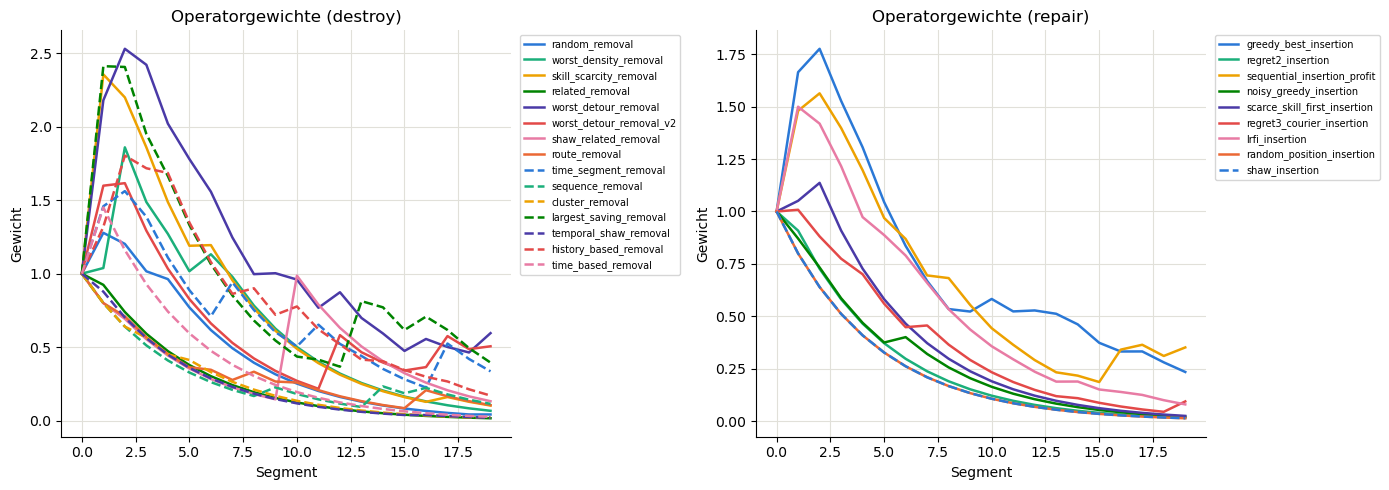

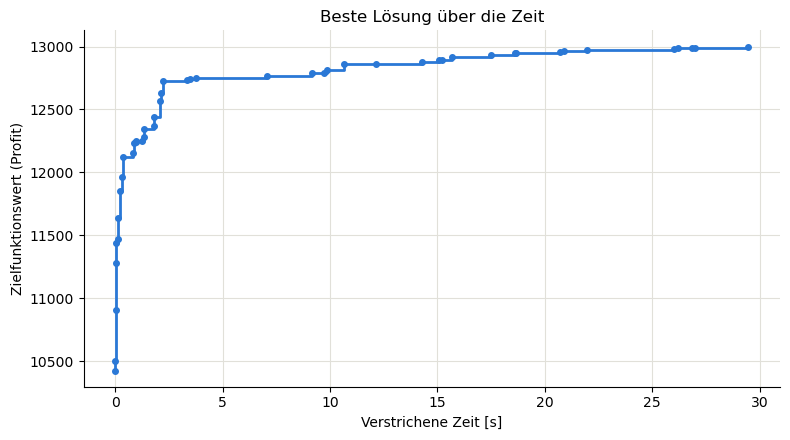

In [13]:
# --- Report-Plots aus den Tracking-CSVs ------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

weights_df = pd.read_csv(TRACK_CSV_DIR / f"{TRACK_PREFIX}operator_weights.csv")
best_df = pd.read_csv(TRACK_CSV_DIR / f"{TRACK_PREFIX}best_solution.csv")

# Feste, colorblind-sichere Farbreihenfolge; ab der 9. Serie gestrichelt
# (Farbe + Linienstil zusammen halten die Serien unterscheidbar).
PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
           "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]


def style_axis(ax):
    ax.grid(color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)


# (a) Gewichtsverlauf je Operator ueber die Segmente
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax, op_type in zip(axes, ("destroy", "repair")):
    sub = weights_df[weights_df["operator_type"] == op_type]
    names = list(dict.fromkeys(sub["operator_name"]))  # feste Reihenfolge

    for i, name in enumerate(names):
        grp = sub[sub["operator_name"] == name]
        ax.plot(grp["segment"], grp["weight"],
                color=PALETTE[i % len(PALETTE)],
                linestyle="-" if i < len(PALETTE) else "--",
                linewidth=1.8, label=name)

    style_axis(ax)
    ax.set_title(f"Operatorgewichte ({op_type})")
    ax.set_xlabel("Segment")
    ax.set_ylabel("Gewicht")
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1.0))

fig.tight_layout()
fig.savefig(TRACK_CSV_DIR / f"{TRACK_PREFIX}operator_weights.png",
            dpi=200, bbox_inches="tight")
plt.show()

# (b) Beste Loesung ueber die Zeit (Treppenfunktion: Bestwert bleibt konstant,
# bis eine neue Bestloesung gefunden wird)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.step(best_df["elapsed_seconds"], best_df["objective_value"],
        where="post", color=PALETTE[0], linewidth=2.0)
ax.plot(best_df["elapsed_seconds"], best_df["objective_value"],
        "o", color=PALETTE[0], markersize=4)
style_axis(ax)
ax.set_title("Beste Lösung über die Zeit")
ax.set_xlabel("Verstrichene Zeit [s]")
ax.set_ylabel("Zielfunktionswert (Profit)")
fig.tight_layout()
fig.savefig(TRACK_CSV_DIR / f"{TRACK_PREFIX}best_solution.png",
            dpi=200, bbox_inches="tight")
plt.show()
